# 07 - Optimización de hiperparámetros: predicción de incidencias

## Predicción de `tiene_incidencia`

En este notebook desarrollo la optimización de hiperparámetros para el problema de clasificación asociado a la variable:

`Tiene_incidencia`

El objetivo es predecir si un envío presentará o no incidencias durante su operación logística.

Esta predicción me parece relevante porque una incidencia puede afectar directamente la eficiencia del proceso logístico, generar costos adicionales, provocar retrasos y afectar la planificación operativa.

A diferencia de la predicción de entrega tardía, este problema tiene una interpretación más directa desde el punto de vista operacional: anticipar si un envío podría presentar problemas durante su ejecución.


# Objetivos del notebook

En este notebook busco:

- analizar nuevamente la variable objetivo `tiene_incidencia`;
- entrenar modelos base como referencia;
- aplicar optimización con `GridSearchCV`;
- aplicar optimización automática con `Optuna`;
- comparar modelos base y optimizados;
- interpretar si realmente la optimización mejora el rendimiento;
- seleccionar el mejor modelo considerando el equilibrio entre `recall` y `f1-score`.

En este problema no me enfoco solamente en el accuracy, porque la variable objetivo presenta desbalance. Por eso, priorizo métricas como `recall`, `f1-score` y `balanced accuracy`.


# 1. Configuración inicial

En esta sección cargo las librerías necesarias para el análisis, entrenamiento de modelos, evaluación y optimización de hiperparámetros.


In [1]:
# Conexión con el proyecto Kedro.
%load_ext kedro.ipython

# Librerías principales.
import pandas as pd
import numpy as np

# Visualización.
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos y validación cruzada.
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

# Pipelines y preprocesamiento.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelos de clasificación.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación.
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Optimización automática.
import optuna

# Configuración visual.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Mostrar más columnas en tablas.
pd.set_option("display.max_columns", None)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


# 2. Carga del dataset final

Cargo el dataset final `dataset_modelo` desde el catálogo de Kedro.

Este dataset ya contiene la integración de envíos, rutas, vehículos e incidencias, además de las variables derivadas creadas en el pipeline de transformación.


In [2]:
df = catalog.load("dataset_modelo")

df.head()


[05/10/26 20:52:07] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=15708915;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=15708916;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1


# 3. Variable objetivo: `tiene_incidencia`

La variable objetivo es:

`tiene_incidencia`

Esta variable indica:

- `0`: envío sin incidencia.
- `1`: envío con incidencia.

Antes de entrenar modelos, reviso su distribución para saber si el problema está balanceado o no.


In [3]:
# Distribución absoluta.
df["tiene_incidencia"].value_counts()



tiene_incidencia
0.0    856
1.0    174
Name: count, dtype: int64

In [4]:
# Distribución porcentual.
df["tiene_incidencia"].value_counts(normalize=True) * 100



tiene_incidencia
0.0    83.106796
1.0    16.893204
Name: proportion, dtype: float64

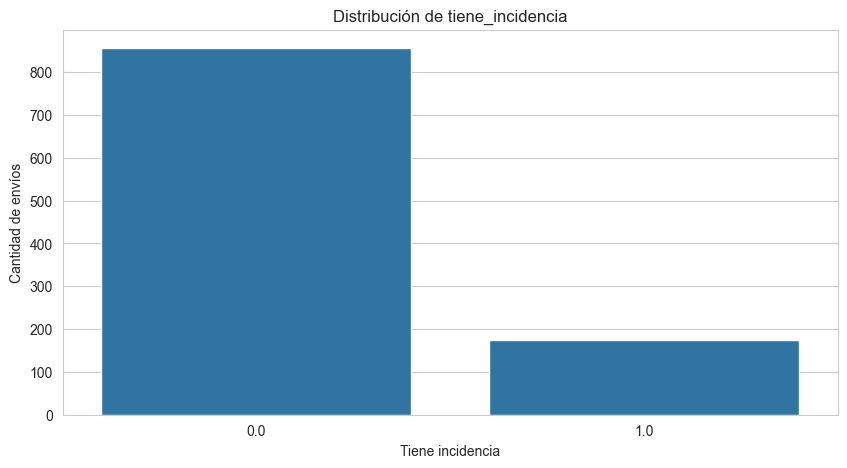

In [5]:
# Visualización de la distribución.
sns.countplot(data=df, x="tiene_incidencia")

plt.title("Distribución de tiene_incidencia")
plt.xlabel("Tiene incidencia")
plt.ylabel("Cantidad de envíos")

plt.show()


## Análisis de la variable objetivo

La variable `tiene_incidencia` presenta la siguiente distribución:

- Clase `0`: 856 registros, equivalente aproximadamente al 83,1%.
- Clase `1`: 174 registros, equivalente aproximadamente al 16,9%.

Esto indica que existe desbalance, porque la mayoría de los envíos no presentan incidencias. Sin embargo, la clase positiva tiene una proporción suficiente para trabajar con modelos de clasificación.

Este punto es importante porque si un modelo predijera siempre que no hay incidencia, podría obtener un accuracy alto, pero no sería útil para el objetivo del proyecto. Por eso, en este análisis no considero el accuracy como métrica principal, sino el `recall`, el `f1-score` y el `balanced accuracy`.


# 4. Selección de variables predictoras

Selecciono variables que podrían influir en la aparición de incidencias.

Evito usar variables que generen fuga de información, por ejemplo:

- `cantidad_incidencias`, porque está directamente relacionada con `tiene_incidencia`;
- `tipo_incidencia_principal`, porque solo existe cuando ya ocurrió una incidencia;
- `costo_total_incidencias`, porque depende de incidencias ocurridas;
- `entrega_tardia`, porque corresponde a otro objetivo predictivo.

Con esto busco que el modelo trabaje con información más realista y disponible antes o durante la planificación logística.


In [6]:
variables_modelo = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "velocidad_promedio_km_h",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo"
]

objetivo = "tiene_incidencia"

X = df[variables_modelo]
y = df[objetivo]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


Dimensiones de X: (1030, 12)
Dimensiones de y: (1030,)


## Análisis de variables seleccionadas

Se seleccionaron 12 variables predictoras.

Estas variables representan factores operativos como distancia, tiempo estimado, capacidad, carga, velocidad promedio, tipo de vía, tipo de carga y estado del vehículo.

La selección tiene sentido logístico porque una incidencia podría estar relacionada con rutas más largas, vehículos más exigidos, tipos de carga específicos o condiciones del vehículo.


# 5. Revisión de valores nulos

Antes de entrenar los modelos reviso si existen valores nulos en las variables seleccionadas.


In [7]:
nulos = X.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0]



capacidad_m3           31
estado_vehiculo        31
capacidad_kg           31
distancia_km           28
tiempo_estimado_hrs    28
tipo_via               28
dtype: int64

## Análisis de nulos

Existen valores nulos en algunas variables como `capacidad_m3`, `estado_vehiculo`, `capacidad_kg`, `distancia_km`, `tiempo_estimado_hrs` y `tipo_via`.

No elimino estos registros porque el dataset no es muy grande y perder información podría afectar el entrenamiento. En su lugar, los nulos se tratarán dentro del pipeline:

- variables numéricas: imputación con mediana;
- variables categóricas: imputación con el valor más frecuente.

Esto mantiene el proceso reproducible y evita modificar directamente el dataset original.


# 6. Preprocesamiento con pipelines

Construyo un preprocesador común para todos los modelos. Esto permite aplicar el mismo tratamiento de datos de forma consistente.


In [8]:
variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)


Variables numéricas:
['distancia_km', 'tiempo_estimado_hrs', 'peso_kg', 'volumen_m3', 'capacidad_kg', 'capacidad_m3', 'uso_capacidad_kg', 'uso_capacidad_m3', 'velocidad_promedio_km_h']

Variables categóricas:
['tipo_via', 'tipo_carga', 'estado_vehiculo']


In [9]:
# Pipeline para variables numéricas.
transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables categóricas.
transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesador general.
preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])


## Análisis del preprocesamiento

El pipeline permite automatizar todo el tratamiento previo al modelo.

Esto es importante porque los modelos no pueden trabajar directamente con valores nulos ni con variables categóricas en texto. Además, al usar pipelines se evita aplicar transformaciones manuales separadas, lo que hace que el experimento sea más limpio y reproducible.


# 7. División en entrenamiento y prueba

Divido el dataset en entrenamiento y prueba.

Uso `stratify=y` para mantener una distribución similar de incidencias en ambos conjuntos.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribución en y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en y_test:")
print(y_test.value_counts(normalize=True) * 100)


X_train: (824, 12)
X_test: (206, 12)

Distribución en y_train:
tiene_incidencia
0.0    83.131068
1.0    16.868932
Name: proportion, dtype: float64

Distribución en y_test:
tiene_incidencia
0.0    83.009709
1.0    16.990291
Name: proportion, dtype: float64


## Análisis de la división

El conjunto de entrenamiento queda con 824 registros y el conjunto de prueba con 206 registros.

La proporción de clases se mantiene prácticamente igual en ambos conjuntos:

- aproximadamente 83% sin incidencia;
- aproximadamente 17% con incidencia.

Esto es importante porque permite evaluar los modelos en un conjunto de prueba representativo del problema original.


# 8. Función de evaluación

Creo una función para evaluar todos los modelos con las mismas métricas.

Las métricas utilizadas son:

- `accuracy`;
- `balanced accuracy`;
- `precision`;
- `recall`;
- `f1-score`;
- matriz de confusión.


In [11]:
def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    """Evalúa un modelo ya entrenado sobre el conjunto de prueba."""

    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"===== {nombre_modelo} =====")
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1-score          : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()

    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


## Criterio de evaluación

En este problema priorizo el `f1-score` porque combina precision y recall.

También observo el recall, ya que detectar incidencias es importante desde el punto de vista operacional. Sin embargo, si el recall sube demasiado y la precision baja mucho, el modelo generará muchas falsas alarmas.

Por eso no basta con mirar una sola métrica.


# 9. Modelos base

Entreno tres modelos base:

- Logistic Regression;
- Decision Tree;
- Random Forest.

Estos modelos sirven como referencia antes de la optimización.


===== Logistic Regression Base =====
Accuracy          : 0.5485
Balanced Accuracy : 0.5463
Precision         : 0.1979
Recall            : 0.5429
F1-score          : 0.2901

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.55      0.67       171
         1.0       0.20      0.54      0.29        35

    accuracy                           0.55       206
   macro avg       0.53      0.55      0.48       206
weighted avg       0.74      0.55      0.60       206



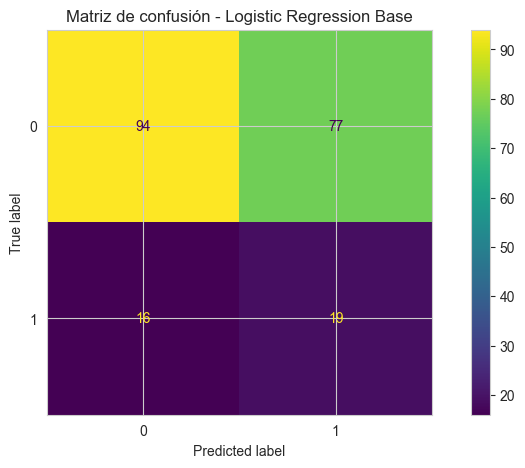

In [12]:
modelo_logistic_base = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(
        random_state=42,
        max_iter=2000,
        class_weight="balanced"
    ))
])

modelo_logistic_base.fit(X_train, y_train)

resultado_logistic_base = evaluar_modelo(
    "Logistic Regression Base",
    modelo_logistic_base,
    X_test,
    y_test
)


## Análisis Logistic Regression Base

Logistic Regression obtiene un recall de aproximadamente 0.54 y un F1-score cercano a 0.29.

Esto significa que detecta un poco más de la mitad de las incidencias reales, aunque con baja precisión. Es decir, logra encontrar casos con incidencia, pero también genera varias falsas alarmas.

Aun así, funciona como una buena línea base para el problema.


===== Decision Tree Base =====
Accuracy          : 0.4272
Balanced Accuracy : 0.5527
Precision         : 0.1926
Recall            : 0.7429
F1-score          : 0.3059

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.36      0.51       171
         1.0       0.19      0.74      0.31        35

    accuracy                           0.43       206
   macro avg       0.53      0.55      0.41       206
weighted avg       0.76      0.43      0.48       206



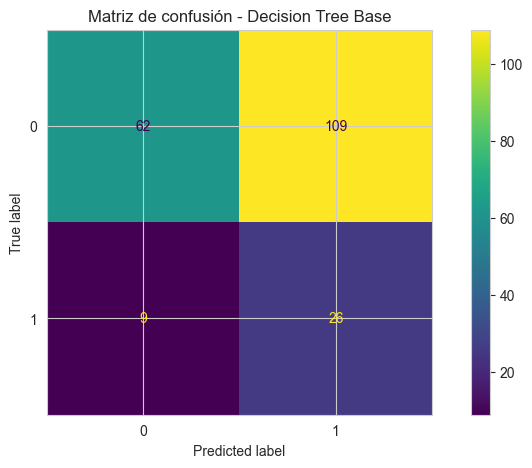

In [13]:
modelo_tree_base = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        max_depth=6,
        class_weight="balanced"
    ))
])

modelo_tree_base.fit(X_train, y_train)

resultado_tree_base = evaluar_modelo(
    "Decision Tree Base",
    modelo_tree_base,
    X_test,
    y_test
)


## Análisis Decision Tree Base

Decision Tree Base obtiene el mejor F1-score entre los modelos base, con un valor aproximado de 0.306.

También alcanza un recall de aproximadamente 0.743, lo que indica que detecta cerca del 74% de las incidencias reales.

Aunque su accuracy es bajo, este resultado es interesante porque el objetivo no es solo acertar los casos sin incidencia, sino detectar correctamente los envíos problemáticos.


===== Random Forest Base =====
Accuracy          : 0.8204
Balanced Accuracy : 0.5055
Precision         : 0.2500
Recall            : 0.0286
F1-score          : 0.0513

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.98      0.90       171
         1.0       0.25      0.03      0.05        35

    accuracy                           0.82       206
   macro avg       0.54      0.51      0.48       206
weighted avg       0.73      0.82      0.76       206



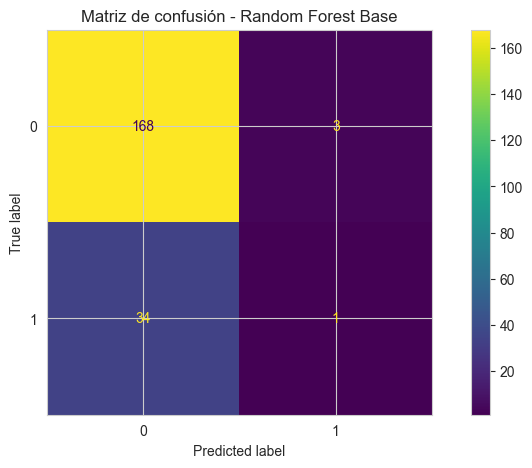

In [14]:
modelo_rf_base = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=8,
        class_weight="balanced"
    ))
])

modelo_rf_base.fit(X_train, y_train)

resultado_rf_base = evaluar_modelo(
    "Random Forest Base",
    modelo_rf_base,
    X_test,
    y_test
)


## Análisis Random Forest Base

Random Forest obtiene un accuracy alto, cercano a 0.82, pero su recall es muy bajo, aproximadamente 0.03.

Esto indica que el modelo casi no detecta incidencias. Probablemente está favoreciendo la clase mayoritaria, es decir, los envíos sin incidencia.

Este resultado demuestra nuevamente que el accuracy puede ser engañoso en problemas desbalanceados.


# 10. Optimización con GridSearchCV - Decision Tree

Optimizo Decision Tree porque fue el mejor modelo base según F1-score.

La búsqueda se realiza mediante `GridSearchCV`, probando distintas combinaciones de hiperparámetros.


In [15]:
pipeline_tree = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid_tree = {
    "modelo__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "modelo__min_samples_split": [2, 5, 10, 20, 30],
    "modelo__min_samples_leaf": [1, 2, 5, 10, 15],
    "modelo__criterion": ["gini", "entropy"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_tree = GridSearchCV(
    estimator=pipeline_tree,
    param_grid=param_grid_tree,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__criterion': ['gini', 'entropy'], 'modelo__max_depth': [2, 3, ...], 'modelo__min_samples_leaf': [1, 2, ...], 'modelo__min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [16]:
print("Mejores parámetros Decision Tree:")
print(grid_tree.best_params_)

print("\nMejor F1 promedio en validación cruzada:")
print(grid_tree.best_score_)


Mejores parámetros Decision Tree:
{'modelo__criterion': 'entropy', 'modelo__max_depth': 3, 'modelo__min_samples_leaf': 10, 'modelo__min_samples_split': 2}

Mejor F1 promedio en validación cruzada:
0.294706764863849


===== Decision Tree GridSearchCV =====
Accuracy          : 0.3107
Balanced Accuracy : 0.5280
Precision         : 0.1796
Recall            : 0.8571
F1-score          : 0.2970

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.20      0.32       171
         1.0       0.18      0.86      0.30        35

    accuracy                           0.31       206
   macro avg       0.53      0.53      0.31       206
weighted avg       0.75      0.31      0.32       206



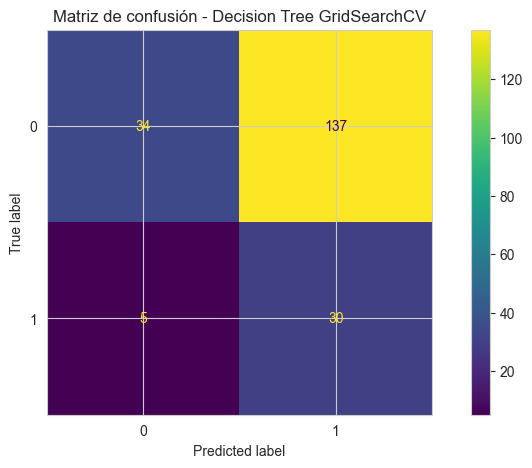

In [17]:
modelo_tree_grid = grid_tree.best_estimator_

resultado_tree_grid = evaluar_modelo(
    "Decision Tree GridSearchCV",
    modelo_tree_grid,
    X_test,
    y_test
)


## Análisis Decision Tree GridSearchCV

GridSearchCV selecciona un árbol con criterio `entropy`, profundidad 3, `min_samples_leaf` igual a 10 y `min_samples_split` igual a 2.

El modelo optimizado alcanza un recall de aproximadamente 0.857, es decir, detecta más incidencias que el árbol base. Sin embargo, su precision disminuye y el F1-score queda levemente por debajo del modelo base.

Esto significa que el modelo optimizado se vuelve más agresivo para detectar incidencias, pero genera más falsas alarmas. Por eso, aunque mejora el recall, no mejora el equilibrio general.


# 11. Optimización con GridSearchCV - Logistic Regression

Optimizo Logistic Regression para revisar si el ajuste de hiperparámetros mejora el rendimiento respecto al modelo base.


In [18]:
pipeline_logistic = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(
        random_state=42,
        max_iter=3000
    ))
])

param_grid_logistic = {
    "modelo__C": [0.01, 0.1, 1, 10, 100],
    "modelo__solver": ["liblinear", "lbfgs"],
    "modelo__class_weight": [None, "balanced"]
}

grid_logistic = GridSearchCV(
    estimator=pipeline_logistic,
    param_grid=param_grid_logistic,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_logistic.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__C': [0.01, 0.1, ...], 'modelo__class_weight': [None, 'balanced'], 'modelo__solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [19]:
print("Mejores parámetros Logistic Regression:")
print(grid_logistic.best_params_)

print("\nMejor F1 promedio en validación cruzada:")
print(grid_logistic.best_score_)


Mejores parámetros Logistic Regression:
{'modelo__C': 100, 'modelo__class_weight': 'balanced', 'modelo__solver': 'liblinear'}

Mejor F1 promedio en validación cruzada:
0.272127596150042


===== Logistic Regression GridSearchCV =====
Accuracy          : 0.5437
Balanced Accuracy : 0.5434
Precision         : 0.1959
Recall            : 0.5429
F1-score          : 0.2879

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.54      0.66       171
         1.0       0.20      0.54      0.29        35

    accuracy                           0.54       206
   macro avg       0.52      0.54      0.48       206
weighted avg       0.74      0.54      0.60       206



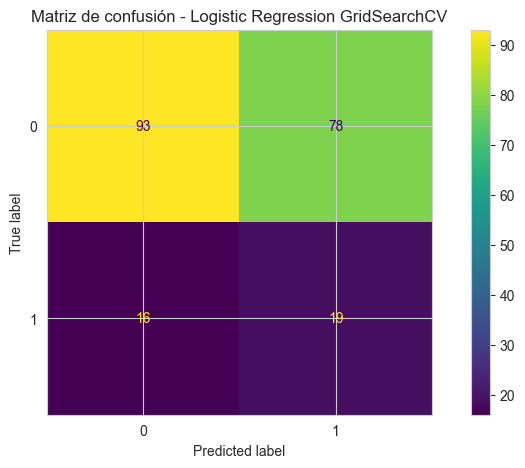

In [20]:
modelo_logistic_grid = grid_logistic.best_estimator_

resultado_logistic_grid = evaluar_modelo(
    "Logistic Regression GridSearchCV",
    modelo_logistic_grid,
    X_test,
    y_test
)


## Análisis Logistic Regression GridSearchCV

La optimización selecciona `C = 100`, `class_weight = balanced` y solver `liblinear`.

El resultado final es muy parecido al modelo base. El recall se mantiene alrededor de 0.543 y el F1-score queda cercano a 0.288.

Esto indica que la optimización no produjo una mejora real sobre Logistic Regression. El modelo ya estaba funcionando cerca de su límite con esta configuración de variables.


# 12. Optimización con GridSearchCV - Random Forest

Random Forest tuvo alto accuracy, pero muy bajo recall. Por eso se intenta optimizar para ver si logra mejorar la detección de incidencias.


In [21]:
pipeline_rf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid_rf = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [4, 6, 8, None],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 5]
}

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__max_depth': [4, 6, ...], 'modelo__min_samples_leaf': [1, 2, ...], 'modelo__min_samples_split': [2, 5, ...], 'modelo__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [22]:
print("Mejores parámetros Random Forest:")
print(grid_rf.best_params_)

print("\nMejor F1 promedio en validación cruzada:")
print(grid_rf.best_score_)


Mejores parámetros Random Forest:
{'modelo__max_depth': 4, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}

Mejor F1 promedio en validación cruzada:
0.13947900484070694


===== Random Forest GridSearchCV =====
Accuracy          : 0.7282
Balanced Accuracy : 0.4840
Precision         : 0.1379
Recall            : 0.1143
F1-score          : 0.1250

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.85      0.84       171
         1.0       0.14      0.11      0.12        35

    accuracy                           0.73       206
   macro avg       0.48      0.48      0.48       206
weighted avg       0.71      0.73      0.72       206



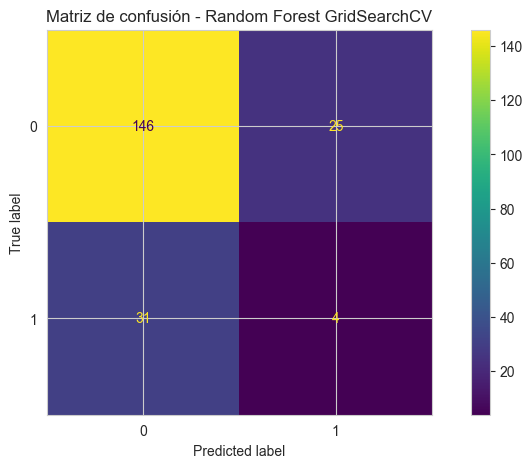

In [23]:
modelo_rf_grid = grid_rf.best_estimator_

resultado_rf_grid = evaluar_modelo(
    "Random Forest GridSearchCV",
    modelo_rf_grid,
    X_test,
    y_test
)


## Análisis Random Forest GridSearchCV

Después de la optimización, Random Forest mejora su recall respecto al modelo base, pero sigue siendo bajo.

El F1-score aumenta de forma leve, pero continúa por debajo de Decision Tree y Logistic Regression.

Por lo tanto, Random Forest no resulta ser una buena opción para este problema, a pesar de su accuracy relativamente alto. Este comportamiento confirma que el modelo sigue favoreciendo principalmente la clase sin incidencia.


# 13. Optimización con Optuna - Decision Tree

Aplico Optuna para realizar una búsqueda automática de hiperparámetros sobre Decision Tree.

Optuna permite explorar combinaciones de forma más flexible que una grilla fija.


In [24]:
def objective_tree(trial):
    """Función objetivo para optimizar Decision Tree con Optuna."""

    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 40)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    modelo = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced",
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion
        ))
    ])

    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    )

    return scores.mean()

study_tree = optuna.create_study(direction="maximize")

study_tree.optimize(objective_tree, n_trials=50)


[I 2026-05-10 20:53:48,625] A new study created in memory with name: no-name-2fefe788-5776-4f96-810f-fe638b0b6740
[I 2026-05-10 20:53:48,739] Trial 0 finished with value: 0.2832818418201206 and parameters: {'max_depth': 8, 'min_samples_split': 27, 'min_samples_leaf': 9, 'criterion': 'gini'}. Best is trial 0 with value: 0.2832818418201206.
[I 2026-05-10 20:53:48,846] Trial 1 finished with value: 0.2047199425615612 and parameters: {'max_depth': 20, 'min_samples_split': 13, 'min_samples_leaf': 18, 'criterion': 'gini'}. Best is trial 0 with value: 0.2832818418201206.
[I 2026-05-10 20:53:48,955] Trial 2 finished with value: 0.2559360574066457 and parameters: {'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 18, 'criterion': 'gini'}. Best is trial 0 with value: 0.2832818418201206.
[I 2026-05-10 20:53:49,064] Trial 3 finished with value: 0.23821625389497497 and parameters: {'max_depth': 12, 'min_samples_split': 31, 'min_samples_leaf': 6, 'criterion': 'entropy'}. Best is trial 0 wi

In [25]:
print("Mejores parámetros Optuna - Decision Tree:")
print(study_tree.best_params)

print("\nMejor F1 promedio en validación cruzada:")
print(study_tree.best_value)


Mejores parámetros Optuna - Decision Tree:
{'max_depth': 3, 'min_samples_split': 9, 'min_samples_leaf': 7, 'criterion': 'entropy'}

Mejor F1 promedio en validación cruzada:
0.2942864203516883


===== Decision Tree Optuna =====
Accuracy          : 0.3107
Balanced Accuracy : 0.5280
Precision         : 0.1796
Recall            : 0.8571
F1-score          : 0.2970

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.20      0.32       171
         1.0       0.18      0.86      0.30        35

    accuracy                           0.31       206
   macro avg       0.53      0.53      0.31       206
weighted avg       0.75      0.31      0.32       206



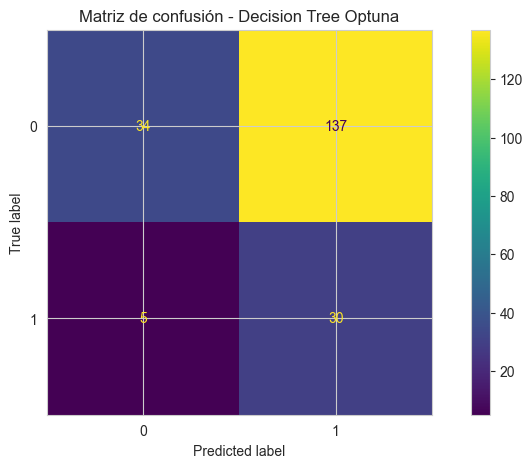

In [26]:
mejores_params_tree = study_tree.best_params

modelo_tree_optuna = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=mejores_params_tree["max_depth"],
        min_samples_split=mejores_params_tree["min_samples_split"],
        min_samples_leaf=mejores_params_tree["min_samples_leaf"],
        criterion=mejores_params_tree["criterion"]
    ))
])

modelo_tree_optuna.fit(X_train, y_train)

resultado_tree_optuna = evaluar_modelo(
    "Decision Tree Optuna",
    modelo_tree_optuna,
    X_test,
    y_test
)


## Análisis Decision Tree Optuna

Optuna encuentra una configuración muy similar a la obtenida con GridSearchCV.

El modelo alcanza un recall cercano a 0.857 y un F1-score cercano a 0.297.

Esto confirma que tanto GridSearchCV como Optuna convergen hacia un árbol más simple y más sensible a la clase positiva. Sin embargo, esta mayor sensibilidad genera más falsas alarmas y no supera al Decision Tree Base en F1-score.

Aun así, Optuna aporta valor al análisis porque confirma de manera independiente una configuración similar a la encontrada por GridSearchCV.


# 14. Comparación final de modelos

Comparo modelos base y optimizados para determinar cuál entrega el mejor rendimiento general.


In [27]:
resultados = [
    resultado_logistic_base,
    resultado_tree_base,
    resultado_rf_base,
    resultado_tree_grid,
    resultado_logistic_grid,
    resultado_rf_grid,
    resultado_tree_optuna
]

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
1,Decision Tree Base,0.427184,0.552715,0.192593,0.742857,0.305882
6,Decision Tree Optuna,0.310680,0.527987,0.179641,0.857143,0.297030
3,Decision Tree GridSearchCV,0.310680,0.527987,0.179641,0.857143,0.297030
0,Logistic Regression Base,0.548544,0.546282,0.197917,0.542857,0.290076
4,Logistic Regression GridSearchCV,0.543689,0.543358,0.195876,0.542857,0.287879
5,Random Forest GridSearchCV,0.728155,0.484043,0.137931,0.114286,0.125000
2,Random Forest Base,0.820388,0.505514,0.250000,0.028571,0.051282


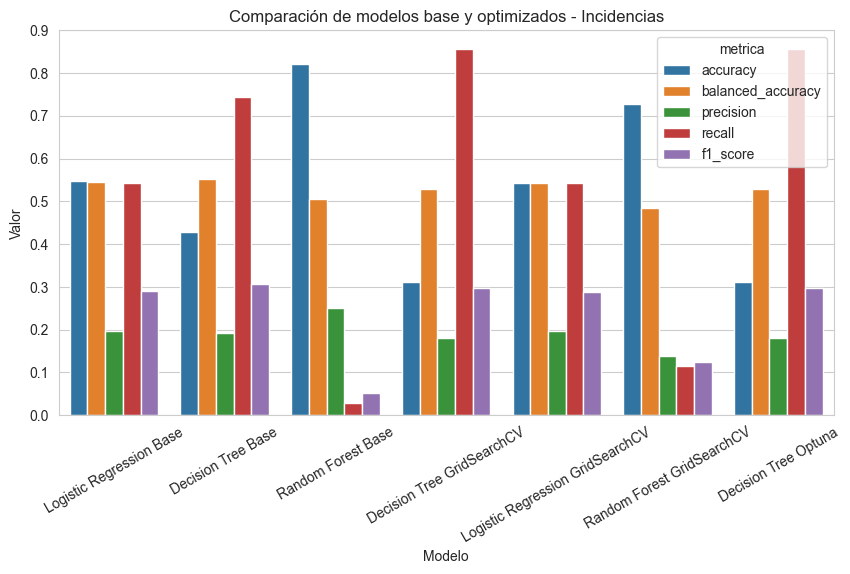

In [28]:
tabla_melt = tabla_resultados.melt(
    id_vars="modelo",
    value_vars=[
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1_score"
    ],
    var_name="metrica",
    value_name="valor"
)

sns.barplot(
    data=tabla_melt,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Comparación de modelos base y optimizados - Incidencias")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=30)

plt.show()


## Análisis comparativo final

La comparación muestra que el mejor modelo por F1-score es `Decision Tree Base`.

Los modelos optimizados con GridSearchCV y Optuna aumentan el recall, llegando a detectar aproximadamente el 86% de las incidencias. Sin embargo, este aumento se logra sacrificando precisión, lo que produce más falsas alarmas.

Por otro lado, Random Forest mantiene un accuracy más alto, pero su bajo recall demuestra que no detecta adecuadamente las incidencias. Por eso no es recomendable como modelo principal en este caso.

En resumen, la optimización no siempre mejora el modelo final. En este caso, el modelo base logra el mejor equilibrio entre detección y precisión.


# 15. Selección del mejor modelo

Selecciono el mejor modelo utilizando principalmente el `f1-score`, porque esta métrica equilibra precision y recall.


In [29]:
mejor_modelo = tabla_resultados.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

mejor_modelo



modelo               Decision Tree Base
accuracy                       0.427184
balanced_accuracy              0.552715
precision                      0.192593
recall                         0.742857
f1_score                       0.305882
Name: 1, dtype: object

## Modelo seleccionado

El modelo seleccionado es:

`Decision Tree Base`

Este modelo obtiene:

- Accuracy aproximado: 0.427
- Balanced Accuracy aproximado: 0.553
- Precision aproximada: 0.193
- Recall aproximado: 0.743
- F1-score aproximado: 0.306

Aunque su accuracy es baja, el modelo logra detectar una proporción importante de incidencias reales. Para este problema, esto es más relevante que simplemente acertar los envíos sin incidencia.


# 16. Conclusiones finales

En este notebook realicé la optimización de hiperparámetros para la predicción de incidencias logísticas.

La variable `tiene_incidencia` resultó ser un objetivo más interesante que `entrega_tardia_v2`, ya que tiene una distribución menos extrema y una interpretación operacional más directa.

Los principales hallazgos fueron:

- El problema sigue presentando desbalance, pero la clase positiva representa cerca del 17% del dataset.
- Logistic Regression funciona como una línea base razonable.
- Random Forest obtiene alto accuracy, pero falla al detectar incidencias.
- Decision Tree Base obtiene el mejor F1-score.
- GridSearchCV y Optuna aumentan el recall, pero reducen la precisión.
- La optimización no logró superar al modelo base en equilibrio general.
- El mejor modelo final es Decision Tree Base.

La conclusión más importante es que, para este problema, no conviene seleccionar el modelo con mayor accuracy. Lo más relevante es evaluar si el modelo detecta correctamente las incidencias.

En términos operacionales, Decision Tree Base es el modelo más equilibrado para anticipar envíos con riesgo de incidencia. Sin embargo, si el objetivo principal fuera detectar la mayor cantidad posible de incidencias, incluso aceptando más falsas alarmas, los modelos optimizados con GridSearchCV u Optuna podrían ser considerados como alternativas.
